# Multi-Regime Comparison: Markowitz vs AI-Gated Stategies

This notebook provides a detailed comparative analysis of five portfolio management strategies, including a new **3-Regime AI-Gated** model:
1. **Markowitz Only (Baseline)**: Standard Mean-Variance optimization.
2. **AI-Gated Markowitz (2-Regime)**: Binary Risk-On (100% MK) / Risk-Off (100% Cash) filter.
3. **Full (AI + Graph + Markowitz)**: 2-Regime filter with Graph-based asset selection (MIS).
4. **AI-Gated Markowitz (3-Regime)**: A smoother allocation strategy:
    *   **Bear (P < 0.48)**: 100% Cash.
    *   **Uncertain (0.48 <= P <= 0.52)**: 50% Cash / 50% Markowitz.
    *   **Bull (P > 0.52)**: 100% Markowitz.
5. **Benchmark**: Buy and Hold Bitcoin (BTC).

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import os

# Config Styling
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")

# Load Data
file_path = './dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"v Loaded {len(data)} rows of data.")
else:
    print("x Data file not found!")

v Loaded 990 rows of data.


## 1. AI Market Regime Training

In [5]:
# Returns calculation
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Feature Engineering
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

# Train/Test Split (Backtest on 2025)
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

# Training the AI Gatekeeper
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)
test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

## 2. Helper Functions: Graph & Markowitz

In [6]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe_ratio(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    try:
        res = minimize(neg_sharpe_ratio, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x))
    except:
        return dict(zip(selected_returns.columns, guess))

## 3. Simulation Engine (Updated for 3-Regime Logic)

In [7]:
def run_simulation(strategy_type, test_dates, returns, probs, lookback=30, corr_threshold=0.5):
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    
    for i, date in enumerate(test_dates[:-1]):
        p_bull = probs.loc[date]
        loc_idx = returns.index.get_loc(date)
        
        if loc_idx < lookback:
            daily_ret = market_return.loc[test_dates[i+1]]
        else:
            window_rets = returns.iloc[loc_idx-lookback:loc_idx]
            
            if strategy_type == 'Markowitz Only':
                weights = optimize_markowitz(window_rets)
                alloc_mk = 1.0
            elif strategy_type == 'AI-Gated (2-Regime)':
                alloc_mk = 1.0 if p_bull > 0.5 else 0.0
                weights = optimize_markowitz(window_rets)
            elif strategy_type == 'Full (AI+Graph+MK)':
                alloc_mk = 1.0 if p_bull > 0.5 else 0.0
                selected = get_mis_assets(window_rets, corr_threshold)
                weights = optimize_markowitz(window_rets[selected])
            elif strategy_type == 'AI-Gated (3-Regime)':
                if p_bull < 0.48:
                    alloc_mk = 0.0
                elif p_bull <= 0.52:
                    alloc_mk = 0.5
                else:
                    alloc_mk = 1.0
                weights = optimize_markowitz(window_rets)
            
            # Calculate Returns
            next_rets = returns.loc[test_dates[i+1]]
            if alloc_mk == 0:
                daily_ret = 0
            else:
                # Risk-On portion return
                mk_ret = sum(w * next_rets[a] for a, w in weights.items() if a in next_rets)
                daily_ret = alloc_mk * mk_ret
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(test_dates[i+1])
        
    return pd.Series(history, index=dates)

## 4. Execution & Comparison

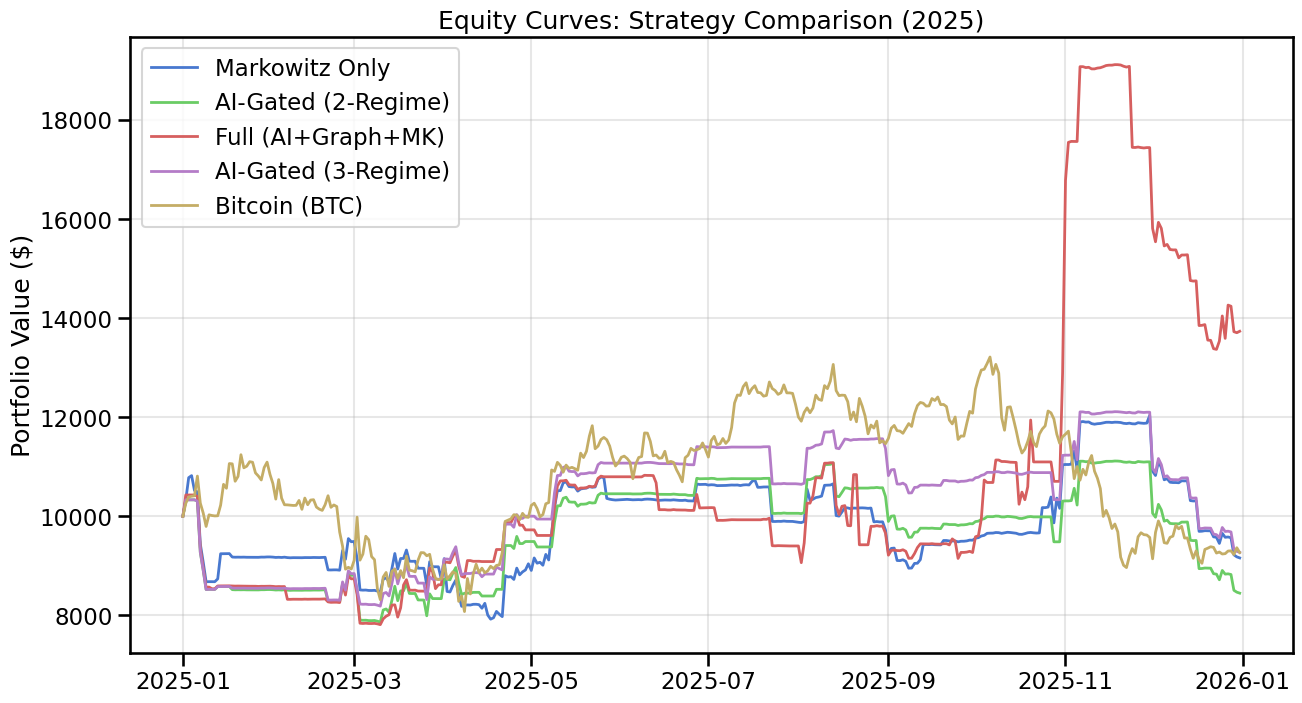

In [8]:
test_dates = X_test.index
res_m = run_simulation('Markowitz Only', test_dates, returns, test_probs)
res_a2 = run_simulation('AI-Gated (2-Regime)', test_dates, returns, test_probs)
res_f = run_simulation('Full (AI+Graph+MK)', test_dates, returns, test_probs)
res_a3 = run_simulation('AI-Gated (3-Regime)', test_dates, returns, test_probs)
res_btc = (data.loc[test_dates, 'BTC-USD'] / data.loc[test_dates[0], 'BTC-USD']) * 10000

all_results = pd.DataFrame({
    'Markowitz Only': res_m,
    'AI-Gated (2-Regime)': res_a2,
    'Full (AI+Graph+MK)': res_f,
    'AI-Gated (3-Regime)': res_a3,
    'Bitcoin (BTC)': res_btc
})

plt.figure(figsize=(15, 8))
for col in all_results.columns:
    plt.plot(all_results[col], label=col, linewidth=2)

plt.title("Equity Curves: Strategy Comparison (2025)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Performance Summary

In [9]:
def get_metrics(series):
    rets = series.pct_change().dropna()
    total_ret = (series.iloc[-1] / series.iloc[0] - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    mdd = ((series / series.cummax()) - 1).min() * 100
    return pd.Series([total_ret, sharpe, mdd], index=['Total Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)'])

metrics = all_results.apply(get_metrics).T
display(metrics.style.background_gradient(cmap='RdYlGn', subset=['Total Return (%)', 'Sharpe Ratio']))

,Total Return (%),Sharpe Ratio,Max Drawdown (%)
Markowitz Only,-8.398380,-0.037106,-26.759189
AI-Gated (2-Regime),-15.503885,-0.277670,-23.981076
Full (AI+Graph+MK),37.319688,0.684272,-30.056128
AI-Gated (3-Regime),-7.281364,-0.058221,-23.435536
Bitcoin (BTC),-7.319368,0.022806,-32.146980
